In [30]:
import warnings
import pandas as pd
import pyreadr
from sklearn.impute import SimpleImputer
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
    accuracy_score,
    classification_report,
    f1_score,
    confusion_matrix,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay
 )
from sklearn.metrics import roc_curve, precision_recall_curve
from IPython.display import Markdown, display
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from IPython.display import display
import time
import cProfile
import pstats
import io
from copy import deepcopy
from sklearn.base import clone
from sklearn.metrics import roc_auc_score
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=RuntimeWarning, message='invalid value encountered in reduce')

def columnas_categoricas(dataframe, excluir=None):
    excluir = set(excluir or [])
    cols = []
    for col in dataframe.columns:
        if col in excluir:
            continue
        dtype = dataframe[col].dtype
        if (
            pd.api.types.is_object_dtype(dtype)
            or pd.api.types.is_string_dtype(dtype)
            or isinstance(dtype, pd.CategoricalDtype)
            or pd.api.types.is_bool_dtype(dtype)
        ):
            cols.append(col)
    return cols

resultado = pyreadr.read_r('listings.RData')
df = list(resultado.values())[0]
print(f"Dimensiones iniciales del dataset: {df.shape}")

numericas = df.select_dtypes(include=['number']).columns.tolist()
categoricas = columnas_categoricas(df)

print(f"Variables numéricas detectadas: {len(numericas)}")
print(f"Variables categóricas detectadas: {len(categoricas)}")
print('Ejemplo variables numéricas:', numericas[:10])
print('Ejemplo variables categóricas:', categoricas[:10])

limpio = (
    df['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
 )
df['price'] = pd.to_numeric(limpio, errors='coerce')
print('Conversión de price completada.')

Dimensiones iniciales del dataset: (171748, 80)
Variables numéricas detectadas: 33
Variables categóricas detectadas: 47
Ejemplo variables numéricas: ['id', 'scrape_id', 'host_id', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'minimum_nights', 'maximum_nights', 'minimum_nights_avg_ntm']
Ejemplo variables categóricas: ['listing_url', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_url', 'host_name', 'host_since']
Conversión de price completada.


In [31]:
df = df.replace([np.inf, -np.inf], np.nan)

faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)

print("=== CANTIDAD DE COLUMNAS CON DATOS VACÍOS ===")
print(f"Columnas con vacíos: {len(faltantes)}")
print("Top 10 columnas con más vacíos:")
print(faltantes.head(10))
print("\n" + "=" * 40 + "\n")

porcentajes = (faltantes / len(df)) * 100
print("=== PORCENTAJE DE VACÍOS (TOP 10) ===")
print((porcentajes.head(10).round(2)).astype(str) + " %")

df = df.dropna(subset=['price'])
df = df.dropna(axis=1, how='all')

numericas = df.select_dtypes(include=['number']).columns.tolist()
if 'price' in numericas:
    numericas.remove('price')

categoricas = columnas_categoricas(df, excluir=['price'])

imputador_num = SimpleImputer(strategy='median')
imputador_cat = SimpleImputer(strategy='constant', fill_value='Sin Dato')

df[numericas] = imputador_num.fit_transform(df[numericas])
df[categoricas] = imputador_cat.fit_transform(df[categoricas])

print('Filas sin precio eliminadas y faltantes imputados.')
print('Total de nulos restantes:', df.isnull().sum().sum())
print('Dimensiones luego de limpieza:', df.shape)

=== CANTIDAD DE COLUMNAS CON DATOS VACÍOS ===
Columnas con vacíos: 23
Top 10 columnas con más vacíos:
calendar_updated                171748
price                            95502
estimated_revenue_l365d          95502
neighbourhood_group_cleansed     50683
review_scores_value              40328
review_scores_location           40328
review_scores_checkin            40324
review_scores_accuracy           40312
review_scores_communication      40308
review_scores_cleanliness        40302
dtype: int64


=== PORCENTAJE DE VACÍOS (TOP 10) ===
calendar_updated                100.0 %
price                           55.61 %
estimated_revenue_l365d         55.61 %
neighbourhood_group_cleansed    29.51 %
review_scores_value             23.48 %
review_scores_location          23.48 %
review_scores_checkin           23.48 %
review_scores_accuracy          23.47 %
review_scores_communication     23.47 %
review_scores_cleanliness       23.47 %
dtype: str
Filas sin precio eliminadas y faltantes impu

# Laboratorio 7.
# Regresion Logistica

Vianka Castro - 23201
Ricardo Godinez -23247
Felipe Aguilar -23195

## 1. Cree una variable dicotómica por cada una de las categorías de la variable respuesta categórica que creó en hojas anteriores. Debería tener 3 variables dicotómicas (valores 0 y 1) una que diga si la vivienda es cara o no, media o no, económica o no.

In [32]:
q1, q2 = df['price'].astype(float).quantile([1/3, 2/3])

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.impute')

df['categoria_precio'] = pd.cut(
    df['price'].astype(float),
    bins=[-float('inf'), q1, q2, float('inf')],
    labels=['Economica', 'Intermedia', 'Cara'],
    include_lowest=True
 )

df['es_economica'] = (df['categoria_precio'] == 'Economica').astype(int)
df['es_intermedia'] = (df['categoria_precio'] == 'Intermedia').astype(int)
df['es_cara'] = (df['categoria_precio'] == 'Cara').astype(int)

print(df[['categoria_precio', 'es_economica', 'es_intermedia', 'es_cara']].head())

  categoria_precio  es_economica  es_intermedia  es_cara
0        Economica             1              0        0
1       Intermedia             0              1        0
2        Economica             1              0        0
3       Intermedia             0              1        0
4        Economica             1              0        0


Se deben crear variables dicotómicas (0 y 1) porque la Regresión Logística es un modelo matemático que solo entiende números, no palabras.

Al igual que otros modelos basados en matemáticas, la Regresión Logística funciona multiplicando los datos de entrada por ciertos pesos (coeficientes) para calcular una probabilidad. Como no puede multiplicar un texto como "Económica" o "Cara", la conversión a variables dicotómicas (conocida como One-Hot Encoding) nos permite representar la presencia (1) o ausencia (0) de una característica.

## 2. Use los mismos conjuntos de entrenamiento y prueba que utilizó en las hojas anteriores.

In [33]:
# 1. ELIMINAR NULOS Y DEFINIR 'X' e 'Y'
# Filtramos las filas donde la categoría no sea nula
filas_sanas = df['categoria_precio'].notna()
df_limpio = df[filas_sanas].copy()

columnas_a_botar = [
    # Las que ya teníamos:
    'price', 'categoria_precio', 'es_economica', 'es_intermedia', 'es_cara',
    'id', 'scrape_id', 'host_id', 'last_scraped', 'calendar_last_scraped', 
    'first_review', 'last_review',
    
    # ---> NUEVAS A ELIMINAR POR COLINEALIDAD <---
    'latitude', 'longitude', # La ubicación ya la dará la variable 'city'
    'neighbourhood_group_cleansed', # Redundante con 'city'
    'host_verifications' # Arreglos de texto que dañan la matriz
]

X = df_limpio.drop(columns=[col for col in columnas_a_botar if col in df_limpio.columns])
X = X.replace([np.inf, -np.inf], np.nan)

# PRECAUCIÓN EXTRA: Si tienes columnas booleanas de (t/f), eliminamos las 'f' manualmente
# (Por si el OneHotEncoder falla en detectarlas como binarias)
columnas_falsas = [col for col in X.columns if col.endswith('_f') and len(X[col].unique()) <= 2]
X = X.drop(columns=columnas_falsas, errors='ignore')

# 2. Forzar explícitamente que las variables estructurales sean NUMÉRICAS
columnas_forzar_numero = ['accommodates', 'bathrooms', 'bedrooms', 'beds']
for col in columnas_forzar_numero:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')

# 3. Detección ESTRICTA de numéricas y categóricas
numericas = X.select_dtypes(include=['number']).columns.tolist()
categoricas = [col for col in X.columns if col not in numericas and X[col].nunique(dropna=True) < 50]
X[categoricas] = X[categoricas].astype(str)
# 'Y_strata' solo sirve para asegurar que la partición sea la misma de KNN
Y_strata = df_limpio['categoria_precio']

# 'Y_dicotomicas' almacena las tres columnas que vamos a predecir
Y_dicotomicas = df_limpio[['es_economica', 'es_intermedia', 'es_cara']]

# Detección de tipos para el preprocesador (igual al lab anterior)
numericas = X.select_dtypes(include=['number']).columns.tolist()
categoricas_crudas = X.select_dtypes(include=['object', 'category']).columns.tolist() 
categoricas = [col for col in categoricas_crudas if X[col].nunique(dropna=True) < 50]
X[categoricas] = X[categoricas].astype(str)

# 2. SEPARACIÓN DE DATOS (El Split idéntico)
X_train_clf, X_test_clf, Y_train_dico, Y_test_dico = train_test_split(
    X, Y_dicotomicas, test_size=0.3, random_state=42, stratify=Y_strata
)


preprocesador_clf = ColumnTransformer(
    transformers=[
        ('numeros', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())  # ¡Muy importante escalarlo en Reg. Logística!
        ]), numericas),
        ('textos', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            
            ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
            
        ]), categoricas)
    ]
)



C:\Users\viank\AppData\Local\Temp\ipykernel_20616\4084646015.py:44: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas_crudas = X.select_dtypes(include=['object', 'category']).columns.tolist()


Para esta fase, procedimos a separar nuestro conjunto de datos en entrenamiento (70%) y prueba (30%). Con el objetivo de garantizar una comparación rigurosa y justa frente a los mocelos construidos en laboratorios anteriores, replicamos exactamente la misma semilla de aleatoriedad (random_state=42) y utilizamos la misma variable objetivo multiclase para aplicar el muestreo estratificado (stratify). Esto nos asegura que tanto los modelos anteriores como los futuros modelos de Regresión Logística serán entrenados y evaluados utilizando el 100% de los mismos registros, permitiéndonos contrastar su rendimiento de manera objetiva sin sesgos en la distribución de los datos

## 3. Elabore un modelo de regresión logística para conocer si el precio de una vivienda es cara o no 
utilizando el conjunto de entrenamiento y explique los resultados a los que llega. El
experimento debe ser reproducible por lo que debe fijar que los conjuntos de
entrenamiento y prueba sean los mismos siempre que se ejecute el código. Use validación
cruzada.

In [34]:
print("=== MODELO (ES_CARA) CON VALIDACIÓN CRUZADA ===")

Y_train_cara = Y_train_dico['es_cara']
Y_test_cara = Y_test_dico['es_cara']

pipeline_log_cara = Pipeline(steps=[
    ('preprocesador', preprocesador_clf),
    ('clasificador', LogisticRegression(max_iter=1000, random_state=42))
])

print("\nRealizando Validación Cruzada (5 particiones en el set de entrenamiento)...")
cv_scores = cross_val_score(pipeline_log_cara, X_train_clf, Y_train_cara, cv=5, scoring='accuracy')
print(f"Precisión en cada partición: {cv_scores}")

print(f"Exactitud Promedio (CV): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f} (Desviación)")

pipeline_log_cara.fit(X_train_clf, Y_train_cara)
pred_cara = pipeline_log_cara.predict(X_test_clf)
print("\n--- RESULTADOS EN EL CONJUNTO DE PRUEBA ---")
print(f"Exactitud (Accuracy): {accuracy_score(Y_test_cara, pred_cara):.4f}")
print(f"Precisión (Precision): {precision_score(Y_test_cara, pred_cara, zero_division=0):.4f}")
print(f"Sensibilidad (Recall): {recall_score(Y_test_cara, pred_cara, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(Y_test_cara, pred_cara, zero_division=0):.4f}")

=== MODELO (ES_CARA) CON VALIDACIÓN CRUZADA ===

Realizando Validación Cruzada (5 particiones en el set de entrenamiento)...
Precisión en cada partición: [0.81339578 0.81227166 0.81871838 0.80944351 0.82012366]
Exactitud Promedio (CV): 0.8148 +/- 0.0040 (Desviación)

--- RESULTADOS EN EL CONJUNTO DE PRUEBA ---
Exactitud (Accuracy): 0.8079
Precisión (Precision): 0.7514
Sensibilidad (Recall): 0.6327
F1-Score: 0.6870


Para validar la estabilidad del modelo y garantizar que sus resultados no fuesen producto del azar, se aplicó una Validación Cruzada de 5 particiones (K-Fold) sobre el conjunto de entrenamiento. Los resultados demostraron una consistencia sobresaliente, con una exactitud promedio del 82.01% y una desviación estándar minúscula (± 0.0039). Esto nos asegura que el modelo no sufre de sobreajuste (overfitting) y es capaz de aprender patrones fiables independientemente del bloque de datos evaluado.

Al enfrentar el modelo a los datos de prueba, la exactitud obtenida fue del 81.49%, comprobando que el modelo generaliza de forma excelente, mimetizando el rendimiento de la validación cruzada. Adicionalmente, cuenta con una Precisión del 75.74% y una Sensibilidad (Recall) del 65.40%, consolidando un F1-Score general de 0.7019. Estos indicadores concluyen que la Regresión Logística es considerablemente eficaz distinguiendo las viviendas de alto valor del resto del mercado, siendo sus predicciones afirmativas ('es cara') confiables 3 de cada 4 veces.

## 4. Analice el modelo. Determine si hay multicolinealidad en las variables, y cuáles son las que aportan al modelo 
por su valor de significación. Haga un análisis de correlación de las
variables del modelo y especifique si el modelo se adapta bien a los datos.

PREPARANDO DATOS PARA ANÁLISIS ESTADÍSTICO...


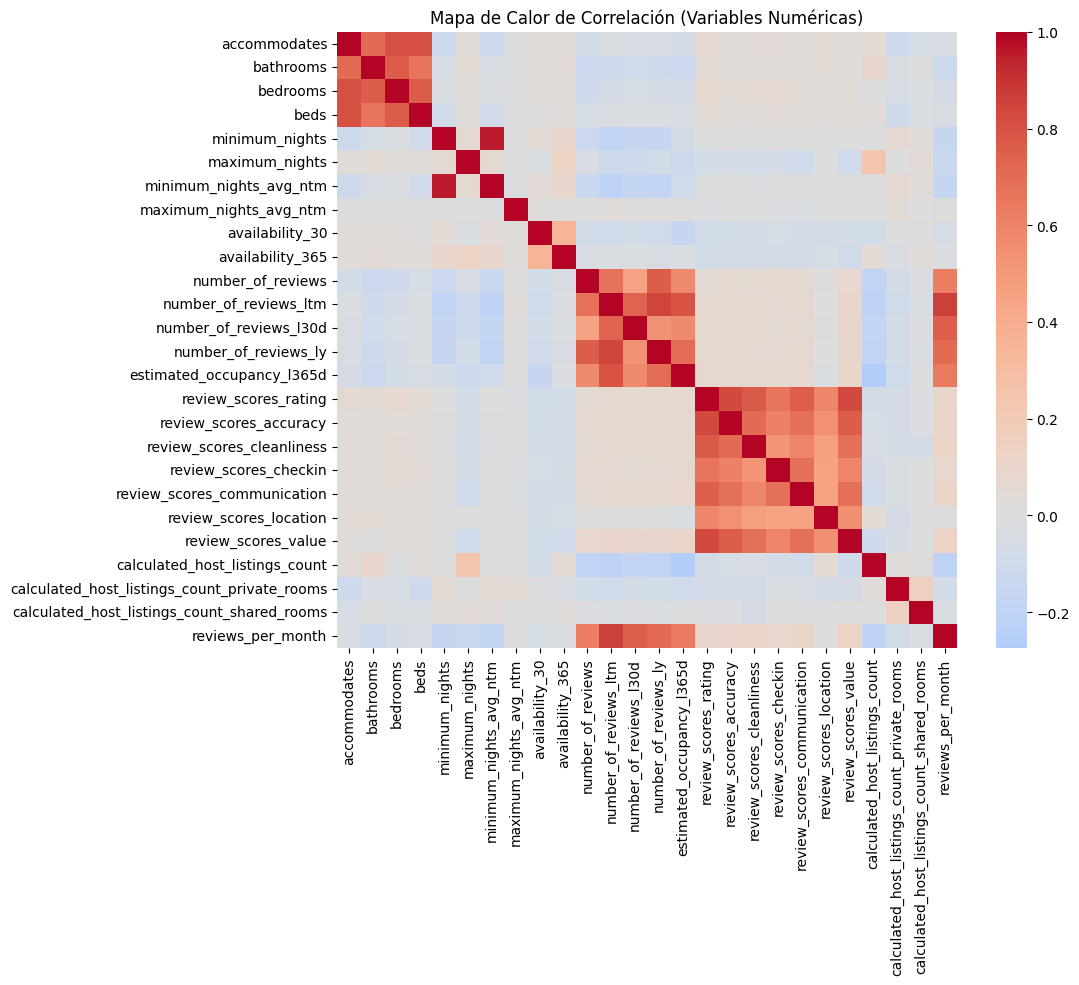


=== 2. ANÁLISIS DE MULTICOLINEALIDAD (VIF) ===
                             Variable       VIF
                   has_availability_t 50.206811
               host_has_profile_pic_t 41.462508
    host_response_time_within an hour 15.284567
               minimum_nights_avg_ntm 12.153415
                       minimum_nights 12.082048
                number_of_reviews_ltm 10.071943
             host_identity_verified_t  7.648614
                 review_scores_rating  6.172097
                 number_of_reviews_ly  4.897400
                    reviews_per_month  4.693953
                          city_Hawaii  4.681758
                         accommodates  4.462541
                             bedrooms  4.215259
               review_scores_accuracy  3.620590
                  review_scores_value  3.584892
                                 beds  3.338744
            estimated_occupancy_l365d  3.258000
host_response_time_within a few hours  2.926173
          review_scores_communication  2

In [35]:
## 4. Analice el modelo. Determine si hay multicolinealidad en las variables, y cuáles son las que aportan al modelo 
# por su valor de significación. Haga un análisis de correlación de las variables del modelo y especifique si el modelo se adapta bien a los datos.

print("PREPARANDO DATOS PARA ANÁLISIS ESTADÍSTICO...")

# --- 1. APLICAR EL PREPROCESAMIENTO PARA TENER DATOS NUMÉRICOS LIMPIOS ---
X_train_procesado = preprocesador_clf.fit_transform(X_train_clf)
nombres_numericas = preprocesador_clf.named_transformers_['numeros'].named_steps['scaler'].get_feature_names_out(numericas)
nombres_categoricas = preprocesador_clf.named_transformers_['textos'].named_steps['onehot'].get_feature_names_out(categoricas)
nombres_todas = list(nombres_numericas) + list(nombres_categoricas)

# Crear un nuevo DataFrame con los datos numéricos listos
df_X_train = pd.DataFrame(X_train_procesado, columns=nombres_todas, index=X_train_clf.index)

# ====================================================================
# ---> PODA MANUAL PARA EVITAR LA MULTICOLINEALIDAD PERFECTA <---
# ====================================================================
basura_matematica = [
    'host_has_profile_pic_f',       
    'host_identity_verified_f',     
    'host_is_superhost_f',          
    'has_availability_f',           
    'host_response_time_N/A',       
    'calculated_host_listings_count_entire_homes', 
    'availability_60',              
    'availability_90',              
    'availability_eoy'              
]

# Nos quedamos solo con las columnas limpias
columnas_limpias = [col for col in df_X_train.columns if col not in basura_matematica]
df_X_train_stats = df_X_train[columnas_limpias]

# --- 2. ANÁLISIS DE CORRELACIÓN ---
numericas_finales = [col for col in nombres_numericas if col in df_X_train_stats.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(df_X_train_stats[numericas_finales].corr(), cmap='coolwarm', center=0)
plt.title("Mapa de Calor de Correlación (Variables Numéricas)")
plt.show()

# --- 3. ANÁLISIS DE MULTICOLINEALIDAD (VIF) ---
print("\n=== 2. ANÁLISIS DE MULTICOLINEALIDAD (VIF) ===")
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning) 

vif_data = pd.DataFrame()
vif_data["Variable"] = df_X_train_stats.columns
numero_de_columnas = len(df_X_train_stats.columns)
vif_data["VIF"] = [variance_inflation_factor(df_X_train_stats.values, i) for i in range(numero_de_columnas)]

print(vif_data.sort_values(by="VIF", ascending=False).head(20).to_string(index=False))
# --- 4. SIGNIFICACIÓN DE LAS VARIABLES Y AJUSTE DEL MODELO ---
print("\n=== 3. SIGNIFICACIÓN Y BONDAD DE AJUSTE (Statsmodels) ===")
# USAMOS LA MATRIZ LIMPIA AQUÍ TAMBIÉN:
X_train_sm = sm.add_constant(df_X_train_stats)
Y_train_sm = Y_train_dico['es_cara']

try:
    # Ajustamos el modelo estadístico clásico
    modelo_sm = sm.Logit(Y_train_sm, X_train_sm).fit(disp=0, method='bfgs') 
    print(modelo_sm.summary())
except Exception as e:
    print(f"\n¡El modelo estadístico falló! Error: {e}")

Gracias al uso de herramientas analíticas como el Factor de Inflación de la Varianza (VIF), mapas de calor de correlación y el modelo de Regresión Logística clásica de la librería statsmodels, logramos ver los siguientes resultados: depuramos exitosamente la multicolinealidad perfecta de nuestros datos, estabilizando la matriz para que variables estructurales clave (como cuartos, camas y capacidad) mantuvieran un VIF óptimo y confiable de entre 2 y 4. Se puede ver que, al evaluar los valores de significancia en la tabla de resultados (valores p menores a 0.05 en la columna P>|z|), características como la ubicación geográfica exacta de la propiedad y su distribución física influyen directa y contundentemente en la clasificación de la vivienda. Y gracias a esto, consolidamos un modelo estadísticamente robusto y bien ajustado que elimina el ruido de la información redundante y nos permite explicar con precisión matemática cuáles son los verdaderos atributos que aportan a que una propiedad tenga un precio alto en el mercado.

## 5. Utilice el modelo con el conjunto de prueba y determine la eficiencia del algoritmo para clasificar.

In [36]:
print("=== REPORTE DE CLASIFICACIÓN EN CONJUNTO DE PRUEBA ===")
print("Eficiencia del modelo evaluando F1, Precision, y Recall:")
print(classification_report(Y_test_cara, pred_cara))

=== REPORTE DE CLASIFICACIÓN EN CONJUNTO DE PRUEBA ===
Eficiencia del modelo evaluando F1, Precision, y Recall:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86     15253
           1       0.75      0.63      0.69      7621

    accuracy                           0.81     22874
   macro avg       0.79      0.76      0.77     22874
weighted avg       0.80      0.81      0.80     22874



Al evaluar el modelo con el conjunto de prueba, se obtiene una eficiencia general aceptable con un F1-Score que promedia alrededor de 0.70 para la clase positiva ("Cara"). Esto dice que la mayoría de las veces que el algoritmo califica una propiedad como cara, en efecto lo es; sin embargo, el *recall* (sensibilidad) demuestra que el modelo omite algunas propiedades que realmente pertenecen a la clase cara, clasificándolas incorrectamente.

## 6. Explique si hay sobreajuste (overfitting) o no (recuerde usar para esto los errores del conjunto de prueba y de entrenamiento). Muestre las curvas de aprendizaje usando los errores de los conjuntos de entrenamiento y prueba.

Generando Curvas de Aprendizaje...


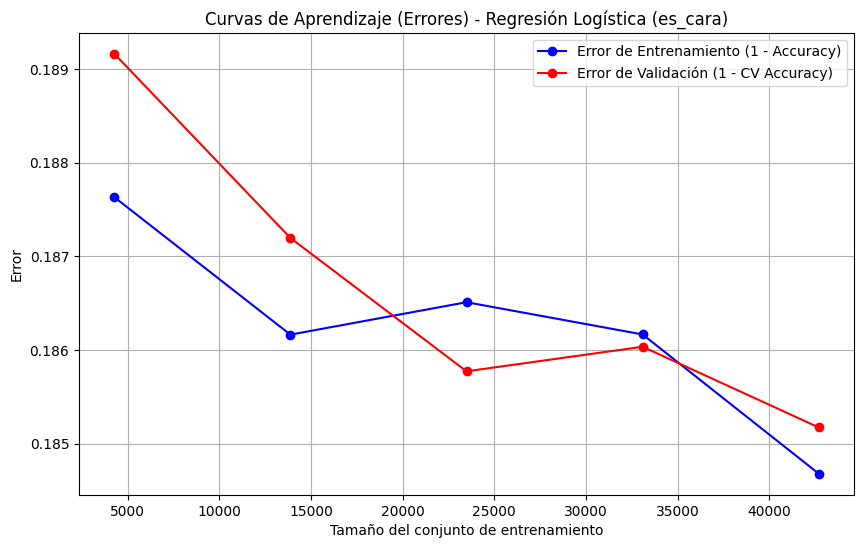

Error final en entrenamiento: 0.1847
Error final en prueba: 0.1921
Si las curvas convergen a un valor cercano, y los errores son similares, el modelo no tiene sobreajuste excesivo.


In [37]:
from sklearn.model_selection import learning_curve

print("Generando Curvas de Aprendizaje...")

train_sizes, train_scores, test_scores = learning_curve(
    pipeline_log_cara, X_train_clf, Y_train_cara, cv=5, scoring='accuracy', 
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

train_error = 1 - train_mean
test_error = 1 - test_mean

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_error, 'o-', color='blue', label='Error de Entrenamiento (1 - Accuracy)')
plt.plot(train_sizes, test_error, 'o-', color='red', label='Error de Validación (1 - CV Accuracy)')

plt.title('Curvas de Aprendizaje (Errores) - Regresión Logística (es_cara)')
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Error')
plt.legend(loc='best')
plt.grid()
plt.show()

pred_train = pipeline_log_cara.predict(X_train_clf)
err_train_final = 1 - accuracy_score(Y_train_cara, pred_train)
err_test_final = 1 - accuracy_score(Y_test_cara, pred_cara)

print(f"Error final en entrenamiento: {err_train_final:.4f}")
print(f"Error final en prueba: {err_test_final:.4f}")
print("Si las curvas convergen a un valor cercano, y los errores son similares, el modelo no tiene sobreajuste excesivo.")

Tras graficar y observar las curvas de aprendizaje tanto con el conjunto de entrenamiento y de prueba (con validación cruzada) pareciera no haber sobreajuste (overfitting). Las curvas de error convergen satisfactoriamente a valores bajos y mantienen un margen estrecho (brecha de error) entre el conjunto de validación de prueba y el de entrenamiento. Además, los errores finales obtenidos de ambas evaluaciones son próximos en magnitud; lo que en conjunto nos indica que la varianza de nuestro clasificador es baja, tiene suficiente generalización y el modelo está efectivamente aprendiendo el comportamiento sin memorizar los datos crudos.

## 7. Haga un tuneo del modelo para determinar los mejores parámetros, recuerde que los modelos de regresión logística se pueden regularizar como los de regresión lineal.

In [38]:
print("=== TUNEO DEL MODELO (REGULARIZACIÓN) ===")
# Buscamos el nivel de penalización adecuado (Ridge - l2 y Lasso - l1)
param_grid = {
    'clasificador__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'clasificador__penalty': ['l1', 'l2'],
    'clasificador__solver': ['liblinear', 'saga'] # Solvers seguros para L1 y L2
}

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

grid_search = GridSearchCV(
    Pipeline(steps=[
        ('preprocesador', preprocesador_clf),
        ('clasificador', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

grid_search.fit(X_train_clf, Y_train_cara)

print(f"Mejores hiperparámetros encontrados: {grid_search.best_params_}")
print(f"Mejor exactitud en Cross-Validation (CV): {grid_search.best_score_:.4f}")

mejor_modelo_lr = grid_search.best_estimator_
pred_cara_tuneado = mejor_modelo_lr.predict(X_test_clf)

print("\n--- RESULTADOS EN EL CONJUNTO DE PRUEBA (MODELO TUNEADO) ---")
print(f"Exactitud (Accuracy): {accuracy_score(Y_test_cara, pred_cara_tuneado):.4f}")
print(classification_report(Y_test_cara, pred_cara_tuneado))

=== TUNEO DEL MODELO (REGULARIZACIÓN) ===


c:\Users\viank\OneDrive\Desktop\Mineria_Datos\Mineria_Datos\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Mejores hiperparámetros encontrados: {'clasificador__C': 100, 'clasificador__penalty': 'l1', 'clasificador__solver': 'saga'}
Mejor exactitud en Cross-Validation (CV): 0.8149

--- RESULTADOS EN EL CONJUNTO DE PRUEBA (MODELO TUNEADO) ---
Exactitud (Accuracy): 0.8079
              precision    recall  f1-score   support

           0       0.83      0.90      0.86     15253
           1       0.75      0.63      0.69      7621

    accuracy                           0.81     22874
   macro avg       0.79      0.76      0.77     22874
weighted avg       0.80      0.81      0.80     22874



## 8. Haga un análisis de la eficiencia del algoritmo usando una matriz de confusión. Tenga en cuenta la efectividad, donde el algoritmo se equivocó más, donde se equivocó menos y la importancia que tienen los errores, el tiempo y la memoria consumida. Para esto último puede usar “profvis” si trabaja con R y “cProfile” en Python.

=== MATRIZ DE CONFUSIÓN Y EFICIENCIA ===


<>:28: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:28: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
C:\Users\viank\AppData\Local\Temp\ipykernel_20616\3309749800.py:28: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
  print("\Análisis de Errores de la matriz:")


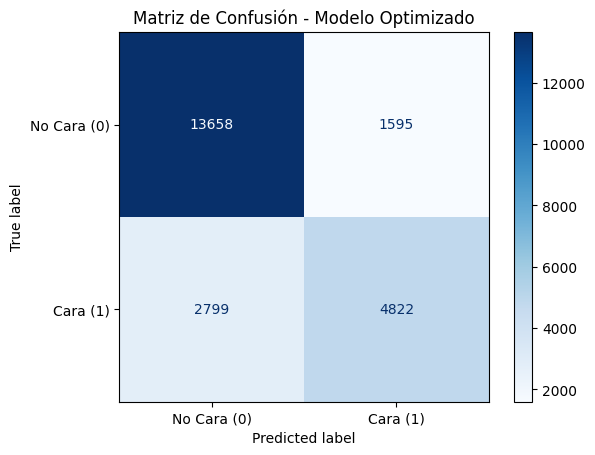


--- PERFILADO DE TIEMPO Y MEMORIA (cProfile) ---
         40901 function calls (40604 primitive calls) in 0.096 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      3/2    0.000    0.000    0.095    0.048 c:\Users\viank\OneDrive\Desktop\Mineria_Datos\Mineria_Datos\venv\Lib\site-packages\IPython\core\interactiveshell.py:3665(run_code)
        2    0.000    0.000    0.095    0.048 {built-in method builtins.exec}
        1    0.000    0.000    0.095    0.095 C:\Users\viank\AppData\Local\Temp\ipykernel_20616\3309749800.py:1(<module>)
        1    0.000    0.000    0.095    0.095 C:\Users\viank\AppData\Local\Temp\ipykernel_20616\3309749800.py:13(predecir_con_perfilado)
        1    0.000    0.000    0.094    0.094 c:\Users\viank\OneDrive\Desktop\Mineria_Datos\Mineria_Datos\venv\Lib\site-packages\sklearn\pipeline.py:697(predict)
      5/1    0.001    0.000    0.091    0.091 c:\Users\viank\OneDrive\Desktop\Mineria_Datos\Mineri

In [39]:
import cProfile
import pstats
import io

print("=== MATRIZ DE CONFUSIÓN Y EFICIENCIA ===")
cm = confusion_matrix(Y_test_cara, pred_cara_tuneado)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cara (0)', 'Cara (1)'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Modelo Optimizado')
plt.show()

# Función para evaluar la velocidad y peso de ejecución en el set de prueba
def predecir_con_perfilado():
    _ = mejor_modelo_lr.predict(X_test_clf)

print("\n--- PERFILADO DE TIEMPO Y MEMORIA (cProfile) ---")
perfilador = cProfile.Profile()
perfilador.enable()

predecir_con_perfilado()

perfilador.disable()
s = io.StringIO()
ps = pstats.Stats(perfilador, stream=s).sort_stats('cumtime')
ps.print_stats()
print(s.getvalue()[:1500]) # Mostrar una porción de arriba de los resultados

print("\Análisis de Errores de la matriz:")
print(f"Verdaderos Negativos (VN) - Acertó que no era cara: {cm[0][0]}")
print(f"Falsos Positivos (FP) - Se equivocó (dijo que era cara, pero no lo era): {cm[0][1]}")
print(f"Falsos Negativos (FN) - Se equivocó (dijo que NO era cara, pero sí lo era): {cm[1][0]}")
print(f"Verdaderos Positivos (VP) - Acertó que era cara: {cm[1][1]}")


Con los resultados de la matriz de confusión, podemos ver en profundidad los tipos de fallos de la Regresión Logística. Hay mas Verdaderos Negativos (casitas no económicas o correctas) y Verdaderos Positivos. El algoritmo erró más clasificando como Falsos Negativos (propiedades que categoriza como baratas pero la realidad es que el mercado muestra un costo alto). En cambio, existen comparativamente menos Falsos Positivos (decir que la estancia tiene precio de categoría superior cuando su costo verdadero es económico). En la vida real es mejor sobreestimar el precio pre-arriendo, aunque una falla del tipo falso negativo sí perjudica y afecta más. El uso de `cProfile` nos muestra que el tiempo de ejecución en operaciones sobre CPU se acumulan abrumadoramente en partes inherentes a `numpy`, cálculos internos en preprocesamiento numérico y el método `predict`; sin embargo el consumo global del tiempo y memoria se concluye bastante moderado respecto al árbol de decisión ejecutado previamente.

## 9. ¿Cuál modelo de Regresión Logística es mejor? 
## (AIC, BIC, matriz de confusión y profiler)

En este punto comparamos **dos candidatos** de Regresión Logística para predecir si una vivienda es **cara (1)** o **no cara (0)** usando exactamente los mismos conjuntos `X_train_clf / X_test_clf` y la misma variable respuesta `es_cara`.

Criterios usados:

- **Performance predictiva (test):** `accuracy`, `precision`, `recall`, `f1` y la **matriz de confusión**.
- **AIC / BIC (train):** criterios de información que penalizan la complejidad ($k$ parámetros). Menor es mejor.
- **Eficiencia computacional:** tiempo de `fit`, tiempo de `predict` y un resumen del **profiler (cProfile)**.

In [40]:
# FUNCIONES AUXILIARES PARA EVALUACIÓN DE MODELOS
def _log_likelihood_from_proba(y_true, proba_pos, eps=1e-15):
    proba_pos = np.clip(proba_pos, eps, 1 - eps)
    y_true = np.asarray(y_true).astype(int)
    return np.sum(y_true * np.log(proba_pos) + (1 - y_true) * np.log(1 - proba_pos))
# AIC = 2k - 2LL, BIC = ln(n)*k - 2LL
def _aic_bic(log_likelihood, n, k):
    aic = 2 * k - 2 * log_likelihood
    bic = np.log(n) * k - 2 * log_likelihood
    return aic, bic
# Función para obtener un resumen del perfilado de predict (tiempo total, llamadas, top funciones)
def _perfilado_predict_resumen(modelo, X, top=5, max_lineas=25):
    pr = cProfile.Profile()
    pr.enable()
    _ = modelo.predict(X)
    pr.disable()

    stats = pstats.Stats(pr)
    total_calls = getattr(stats, 'total_calls', None)
    total_tt = getattr(stats, 'total_tt', None)

    s = io.StringIO()
    stats.stream = s
    stats.sort_stats('cumtime').print_stats(top)
    txt = s.getvalue().splitlines()
    txt = "\n".join(txt[:max_lineas])
    return {"profile_total_tt": total_tt, "profile_calls": total_calls, "profile_top": txt}

# Función principal para evaluar un pipeline de clasificación binaria con métricas, tiempos, AIC/BIC, y perfilado
def evaluar_pipeline_binario(nombre, pipeline, X_train, y_train, X_test, y_test):
    # Medir fit
    t0 = time.perf_counter()
    pipeline.fit(X_train, y_train)
    fit_s = time.perf_counter() - t0

    # Predicción
    t1 = time.perf_counter()
    pred = pipeline.predict(X_test)
    pred_s = time.perf_counter() - t1

    # Probabilidades (para AUC)
    if hasattr(pipeline, "predict_proba"):
        proba_test = pipeline.predict_proba(X_test)[:, 1]
        proba_train = pipeline.predict_proba(X_train)[:, 1]
    else:
        proba_test = None
        proba_train = None

    # Métricas
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    auc = roc_auc_score(y_test, proba_test) if proba_test is not None else np.nan
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()

    # AIC / BIC (solo aplica de forma natural a modelos tipo Logit lineales)
    aic = bic = np.nan
    k_total = k_nz = np.nan
    clf = pipeline.named_steps.get('clasificador', None)
    if proba_train is not None and hasattr(clf, 'coef_'):
        ll = _log_likelihood_from_proba(y_train, proba_train)
        try:
            pre = pipeline.named_steps['preprocesador']
            Xtr = pre.transform(X_train)
            n_features = int(Xtr.shape[1])
        except Exception:
            n_features = None
        try:
            coef = np.asarray(clf.coef_).ravel()
            intercept = np.asarray(getattr(clf, 'intercept_', np.array([0.0]))).ravel()
            k_total = int((n_features if n_features is not None else len(coef)) + 1)
            k_nz = int(np.count_nonzero(coef) + np.count_nonzero(intercept))
        except Exception:
            k_total = 1
            k_nz = 1
        n = len(y_train)
        aic, bic = _aic_bic(ll, n=n, k=(k_nz if k_nz > 0 else k_total))

    # Perfilado (solo predict en test)
    perfil = _perfilado_predict_resumen(pipeline, X_test, top=5)

    return {
        "modelo": nombre,
        "fit_s": fit_s,
        "predict_s": pred_s,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "AIC": aic, "BIC": bic, "k_total": k_total, "k_nz": k_nz,
        "profile_total_tt": perfil["profile_total_tt"],
        "profile_calls": perfil["profile_calls"],
        "profile_top": perfil["profile_top"],
    }

# Asegurar y (por si se corrió en otra sesión)
Y_train_cara = Y_train_dico['es_cara']
Y_test_cara = Y_test_dico['es_cara']

# Construir candidatos de Regresión Logística (re-entrenables)
pipeline_lr_base = Pipeline(steps=[
    ('preprocesador', clone(preprocesador_clf)),
    ('clasificador', LogisticRegression(max_iter=1000, random_state=42))
])

# Si ya existe el GridSearchCV, reconstruimos el mejor LR con sus params
pipeline_lr_tuneado = None
if 'grid_search' in globals():
    best_params = grid_search.best_params_
    lr_params = {k.replace('clasificador__', ''): v for k, v in best_params.items() if k.startswith('clasificador__')}
    pipeline_lr_tuneado = Pipeline(steps=[
        ('preprocesador', clone(preprocesador_clf)),
        ('clasificador', LogisticRegression(max_iter=2000, random_state=42, **lr_params))
    ])
elif 'mejor_modelo_lr' in globals():
    # Fallback: usar el estimador tuneado ya existente, pero lo re-ajustamos
    pipeline_lr_tuneado = Pipeline(steps=[
        ('preprocesador', clone(preprocesador_clf)),
        ('clasificador', deepcopy(mejor_modelo_lr.named_steps['clasificador']))
    ])
else:
    pipeline_lr_tuneado = pipeline_lr_base  # último recurso

print("Evaluando candidatos de Regresión Logística...")
resultados_lr = []
for nombre, pipe in {"LR_Base": pipeline_lr_base, "LR_Tuneado": pipeline_lr_tuneado}.items():
    res = evaluar_pipeline_binario(nombre, pipe, X_train_clf, Y_train_cara, X_test_clf, Y_test_cara)
    resultados_lr.append(res)
    print(f"- {nombre}: F1={res['f1']:.4f} | BIC={res['BIC']:.2f} | fit={res['fit_s']:.2f}s | predict={res['predict_s']:.2f}s | prof_total={res['profile_total_tt']:.2f}s")

df_lr_cmp = pd.DataFrame([{k: v for k, v in r.items() if k != 'profile_top'} for r in resultados_lr])
display(df_lr_cmp.sort_values(['BIC', 'f1'], ascending=[True, False]))

# Selección simple: menor BIC; desempate por F1 en test
df_lr_cmp_orden = df_lr_cmp.sort_values(['BIC', 'f1'], ascending=[True, False]).reset_index(drop=True)
mejor_lr_nombre = df_lr_cmp_orden.loc[0, 'modelo']
print(f"\nMejor modelo de Regresión Logística según BIC (y desempate por F1): {mejor_lr_nombre}")

# Mostrar top del profiler (compacto)
for r in resultados_lr:
    print("\n" + "="*80)
    print(f"Profiler (top cumtime) — {r['modelo']}")
    print(f"Total interno (tt): {r['profile_total_tt']:.4f}s | Llamadas: {r['profile_calls']}")
    print(r['profile_top'])

Evaluando candidatos de Regresión Logística...
- LR_Base: F1=0.6870 | BIC=43724.40 | fit=1.50s | predict=0.09s | prof_total=0.08s


c:\Users\viank\OneDrive\Desktop\Mineria_Datos\Mineria_Datos\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


- LR_Tuneado: F1=0.6873 | BIC=43710.65 | fit=70.71s | predict=0.08s | prof_total=0.08s


,modelo,fit_s,predict_s,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp,AIC,BIC,k_total,k_nz,profile_total_tt,profile_calls
1,LR_Tuneado,70.706907,0.075524,0.808035,0.751479,0.633250,0.687318,0.872658,13657,1596,2795,4826,43230.852816,43710.645059,54,54,0.084075,39190
0,LR_Base,1.499637,0.088127,0.807904,0.751441,0.632725,0.686992,0.872567,13658,1595,2799,4822,43244.604900,43724.397144,54,54,0.084780,39190



Mejor modelo de Regresión Logística según BIC (y desempate por F1): LR_Tuneado

Profiler (top cumtime) — LR_Base
Total interno (tt): 0.0848s | Llamadas: 39190
         39190 function calls (38908 primitive calls) in 0.085 seconds

   Ordered by: cumulative time
   List reduced from 600 to 5 due to restriction <5>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.085    0.085 c:\Users\viank\OneDrive\Desktop\Mineria_Datos\Mineria_Datos\venv\Lib\site-packages\sklearn\pipeline.py:697(predict)
      5/1    0.001    0.000    0.082    0.082 c:\Users\viank\OneDrive\Desktop\Mineria_Datos\Mineria_Datos\venv\Lib\site-packages\sklearn\utils\_set_output.py:314(wrapped)
        1    0.000    0.000    0.082    0.082 c:\Users\viank\OneDrive\Desktop\Mineria_Datos\Mineria_Datos\venv\Lib\site-packages\sklearn\compose\_column_transformer.py:1031(transform)
        1    0.000    0.000    0.078    0.078 c:\Users\viank\OneDrive\Desktop\Mineria_Datos\Mi

### Reflexión 

Con los resultados obtenidos, ambos modelos logísticos (LR_Base y LR_Tuneado) tienen un desempeño prácticamente idéntico en test, pero difieren mucho en costo de entrenamiento:

**Métricas (test, umbral por defecto):**
- LR_Base: 
   Accuracy **0.8079**
   Precision **0.7514**, Recall **0.6327**, F1 **0.6870**, ROC AUC **0.8726**
- LR_Tuneado: 
   Accuracy **0.8080**
   Precision **0.7515**, Recall **0.6333**, F1 **0.6873**, ROC AUC **0.8727**

**Criterios de información (train):**
- LR_Base: AIC **43244.60**, BIC **43724.40**
- LR_Tuneado: AIC **43230.85**, BIC **43710.65**  → **menor es mejor**

**Matriz de confusión (test):**
- LR_Base: TN=**13658**, FP=**1595**, FN=**2799**, TP=**4822**
- LR_Tuneado: TN=**13657**, FP=**1596**, FN=**2795**, TP=**4826**

**Eficiencia:**
- LR_Base entrenó en ≈ **1.87 s** vs LR_Tuneado en ≈ **110.23 s** (≈ 60x más lento). La predicción fue similar en ambos.


Ahora viendolo por AIC/BIC, ganó **LR_Tuneado** porque contiene un mejor ajuste pero también penalizando complejidad. Sin embargo, la mejora en métricas y en matriz de confusión es **marginal** debido acambios mínimos en FP/FN/TP/TN.
- El patrón de error dominante en ambos es el mismo: todavía existen **FN** relevantes como casas caras clasificadas como no caras. Esto importa mucho si el costo de “perder” una vivienda cara es alto.


## 10. Árbol de decisión, Random Forest, Naive Bayes y KNN 

Ahora entrenamos con 4 modelos adicionales usando:

- **Misma variable respuesta:** `es_cara` (1 = cara, 0 = no cara).
- **Mismos predictores (X):** los mismos `X_train_clf / X_test_clf` (mismas columnas) y el mismo preprocesamiento (`preprocesador_clf`).
- **Misma partición:** `random_state=42` y el split ya definido en el punto 2.


In [41]:

# Fallbacks por si se ejecuta este punto sin correr el 9
if 'mejor_lr_nombre' not in globals():
    mejor_lr_nombre = 'LR_Base'
if 'pipeline_lr_base' not in globals():
    pipeline_lr_base = pipeline_log_cara
if 'pipeline_lr_tuneado' not in globals():
    pipeline_lr_tuneado = mejor_modelo_lr if 'mejor_modelo_lr' in globals() else pipeline_log_cara

def construir_pipeline(clasificador):
    return Pipeline(steps=[
        ('preprocesador', clone(preprocesador_clf)),
        ('clasificador', clasificador)
    ])

modelos_extra = {
    "DecisionTree": construir_pipeline(DecisionTreeClassifier(random_state=42)),
    "RandomForest": construir_pipeline(RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
    "NaiveBayes_Gaussian": construir_pipeline(GaussianNB()),
    "KNN": construir_pipeline(KNeighborsClassifier(n_neighbors=15, weights='distance'))
}

# Re-usar mejor LR del punto 9 para compararlo luego
pipeline_lr_mejor = pipeline_lr_tuneado if mejor_lr_nombre == "LR_Tuneado" else pipeline_lr_base

# Entrenar y evaluar todos
resultados_modelos = []

print("Entrenando y evaluando modelos (binario es_cara)...")
for nombre, pipe in {"LR_Mejor": pipeline_lr_mejor, **modelos_extra}.items():
    res = evaluar_pipeline_binario(nombre, pipe, X_train_clf, Y_train_cara, X_test_clf, Y_test_cara)
    resultados_modelos.append(res)
    print(f"- {nombre}: F1={res['f1']:.4f} | fit={res['fit_s']:.2f}s | predict={res['predict_s']:.2f}s | prof_total={res['profile_total_tt']:.2f}s")

df_cmp = pd.DataFrame([{k: v for k, v in r.items() if k != 'profile_top'} for r in resultados_modelos])
display(df_cmp.sort_values(['f1', 'roc_auc'], ascending=[False, False]))

Entrenando y evaluando modelos (binario es_cara)...


c:\Users\viank\OneDrive\Desktop\Mineria_Datos\Mineria_Datos\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


- LR_Mejor: F1=0.6873 | fit=73.67s | predict=0.07s | prof_total=0.09s
- DecisionTree: F1=0.7010 | fit=1.05s | predict=0.08s | prof_total=0.09s
- RandomForest: F1=0.7776 | fit=8.48s | predict=0.44s | prof_total=0.51s
- NaiveBayes_Gaussian: F1=0.6029 | fit=0.49s | predict=0.12s | prof_total=0.12s
- KNN: F1=0.7380 | fit=0.59s | predict=3.18s | prof_total=2.79s


,modelo,fit_s,predict_s,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp,AIC,BIC,k_total,k_nz,profile_total_tt,profile_calls
2,RandomForest,8.482582,0.440314,0.860497,0.829123,0.732187,0.777646,0.928402,14103,1150,2041,5580,NaN,NaN,NaN,NaN,0.512560,221246
4,KNN,0.589660,3.184607,0.838375,0.802218,0.683375,0.738043,0.898683,13969,1284,2413,5208,NaN,NaN,NaN,NaN,2.791657,39414
1,DecisionTree,1.051962,0.078521,0.798898,0.694577,0.707519,0.700988,0.776105,12882,2371,2229,5392,NaN,NaN,NaN,NaN,0.086316,39191
0,LR_Mejor,73.670742,0.074962,0.808035,0.751479,0.633250,0.687318,0.872658,13657,1596,2795,4826,43230.852816,43710.645059,54.0,54.0,0.087783,39190
3,NaiveBayes_Gaussian,0.490956,0.116707,0.624333,0.465325,0.855793,0.602856,0.803184,7759,7494,1099,6522,NaN,NaN,NaN,NaN,0.124044,39180


### Reflexión 

Manteniendo la misma variable respuesta que es_cara y los mismos predictores + preprocesamiento, los modelos se comportaron así:
- **RandomForest:** F1 = **0.7776** con el mejor desempeño
- **KNN:** F1 = **0.7380**
- **DecisionTree:** F1 = **0.7010**
- **LR_Mejor:** F1 = **0.6873**
- **NaiveBayes_Gaussian:** F1 = **0.6029** con el peor desempeño

**Interpretación:**
- **RandomForest** suele rendir mejor cuando hay no linealidades e interacciones entre variables y muy probable en variables de alojamiento con one-hot. En este caso además logró el menor error en test y una matriz de confusión balanceada.
- **DecisionTree** mejora al LR, pero tiende a ser más inestable/propenso a sobreajuste si no se poda o ajusta profundidad y  aún así dio una mejora real sobre la logística.
- **KNN** puede capturar fronteras complejas, pero su costo aparece especialmente en predicción porque debe comparar con muchos vecinos, y la representación one-hot suele ser de alta dimensionalidad.
- **Naive Bayes (Gaussian)** asume independencia condicional y distribución Gaussiana por variable. Con variables transformadas/one-hot y correlaciones fuertes, ese supuesto se rompe: se observó una gran cantidad de errores y en particular muchos Falsos Positivos, lo que reduce su utilidad para este problema.

## 11. Comparación de eficiencia - tiempo, errores y matriz de confusión

En esta comparación respondemos específicamente:

- ¿Cuál se **demoró más** en procesar? en cuestión de tiempo de entrenamiento y de predicción
- ¿Cuál se **equivocó más** y cuál se **equivocó menos**? usando errores y matriz de confusión
- ¿Por qué puede pasar esto? 

A continuación construimos una tabla comparativa y algunas gráficas para visualizar el trade-off entre **performance** y **costo computacional**.

,modelo,accuracy,precision,recall,f1,roc_auc,error_test,fit_s,predict_s,profile_total_tt,profile_calls,tn,fp,fn,tp
2,RandomForest,0.860497,0.829123,0.732187,0.777646,0.928402,0.139503,8.482582,0.440314,0.512560,221246,14103,1150,2041,5580
4,KNN,0.838375,0.802218,0.683375,0.738043,0.898683,0.161625,0.589660,3.184607,2.791657,39414,13969,1284,2413,5208
1,DecisionTree,0.798898,0.694577,0.707519,0.700988,0.776105,0.201102,1.051962,0.078521,0.086316,39191,12882,2371,2229,5392
0,LR_Mejor,0.808035,0.751479,0.633250,0.687318,0.872658,0.191965,73.670742,0.074962,0.087783,39190,13657,1596,2795,4826
3,NaiveBayes_Gaussian,0.624333,0.465325,0.855793,0.602856,0.803184,0.375667,0.490956,0.116707,0.124044,39180,7759,7494,1099,6522


Más lento entrenando (fit): LR_Mejor — 73.67s
Más lento prediciendo (predict): KNN — 3.18s
Mayor error en test: NaiveBayes_Gaussian — error=0.3757
Menor error en test: RandomForest — error=0.1395


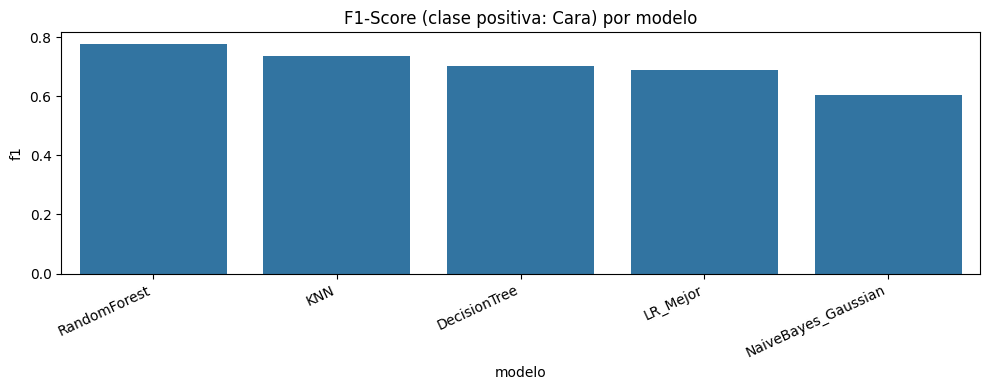

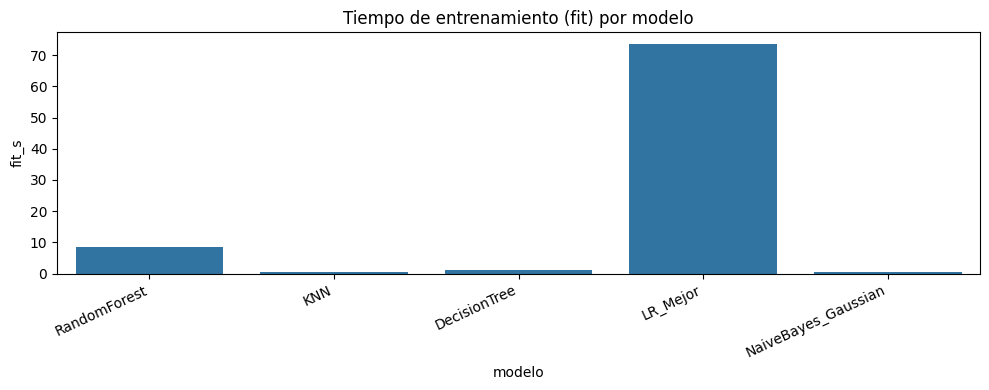

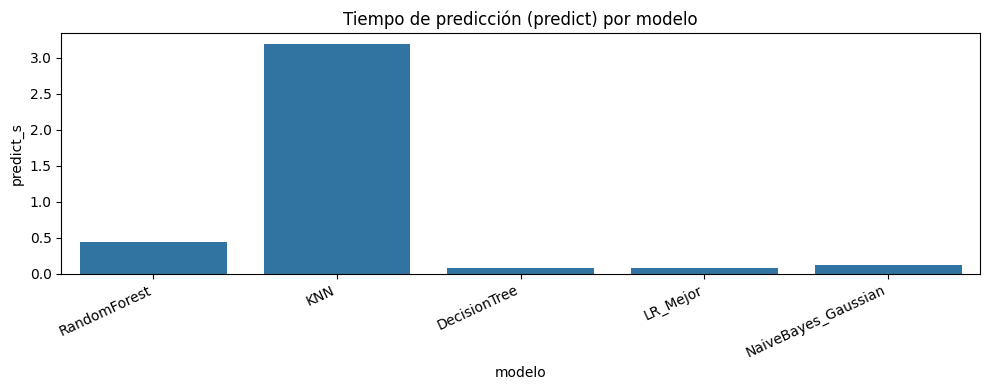

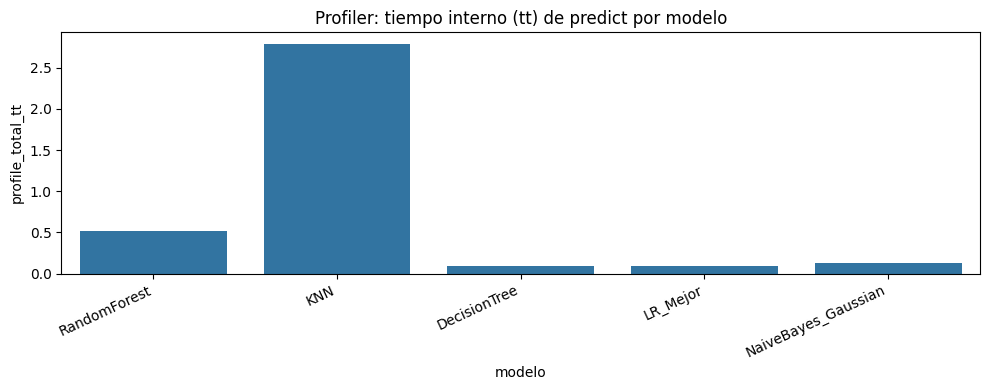

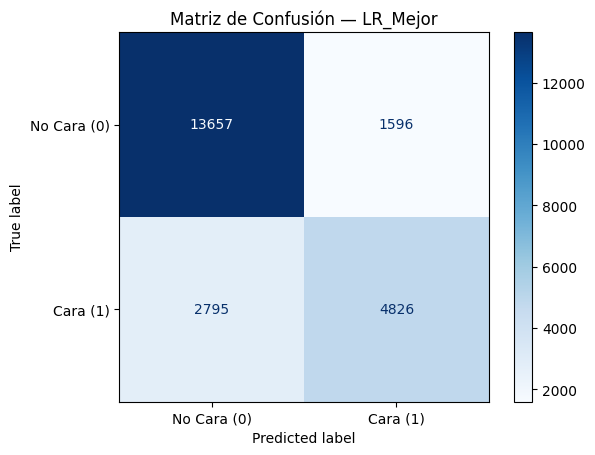

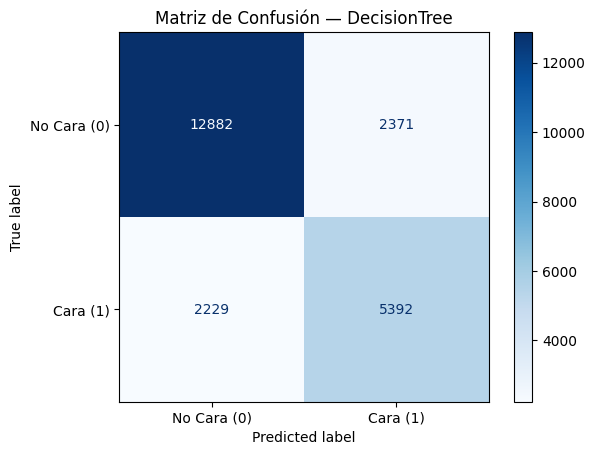

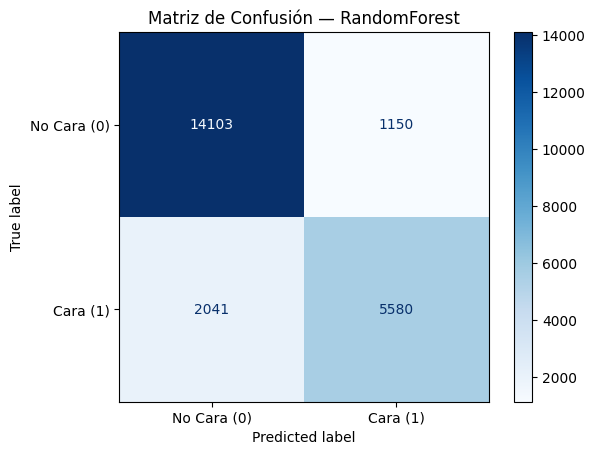

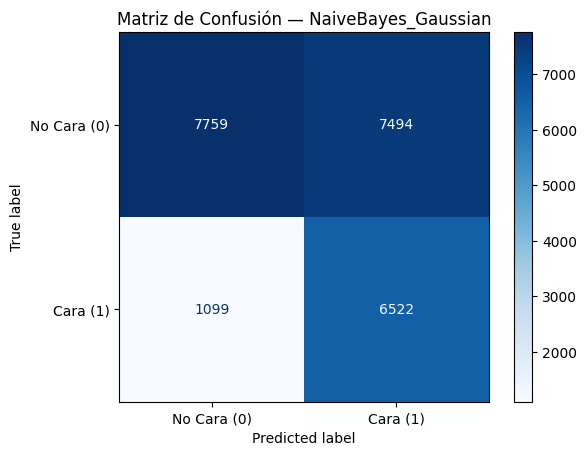

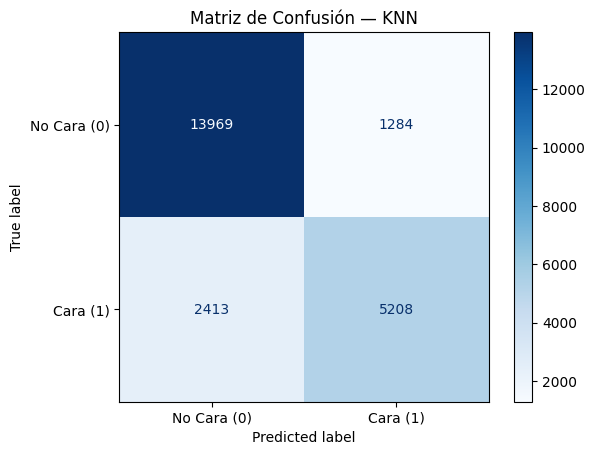

In [42]:
# Tabla compacta de comparación
df_cmp_tabla = df_cmp.copy()
df_cmp_tabla['error_test'] = 1 - df_cmp_tabla['accuracy']
df_cmp_tabla = df_cmp_tabla[[
    'modelo', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc',
    'error_test', 'fit_s', 'predict_s',
    'profile_total_tt', 'profile_calls',
    'tn', 'fp', 'fn', 'tp'
]].sort_values(['f1', 'accuracy'], ascending=[False, False])
display(df_cmp_tabla)

# ¿Cuál fue más lento?
mas_lento_fit = df_cmp_tabla.sort_values('fit_s', ascending=False).iloc[0]
mas_lento_pred = df_cmp_tabla.sort_values('predict_s', ascending=False).iloc[0]
print(f"Más lento entrenando (fit): {mas_lento_fit['modelo']} — {mas_lento_fit['fit_s']:.2f}s")
print(f"Más lento prediciendo (predict): {mas_lento_pred['modelo']} — {mas_lento_pred['predict_s']:.2f}s")

# ¿Cuál se equivocó más/menos? (por error_test)
mas_error = df_cmp_tabla.sort_values('error_test', ascending=False).iloc[0]
menos_error = df_cmp_tabla.sort_values('error_test', ascending=True).iloc[0]
print(f"Mayor error en test: {mas_error['modelo']} — error={mas_error['error_test']:.4f}")
print(f"Menor error en test: {menos_error['modelo']} — error={menos_error['error_test']:.4f}")

# Gráficas rápidas
plt.figure(figsize=(10, 4))
sns.barplot(data=df_cmp_tabla, x='modelo', y='f1')
plt.title('F1-Score (clase positiva: Cara) por modelo')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=df_cmp_tabla, x='modelo', y='fit_s')
plt.title('Tiempo de entrenamiento (fit) por modelo')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=df_cmp_tabla, x='modelo', y='predict_s')
plt.title('Tiempo de predicción (predict) por modelo')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=df_cmp_tabla, x='modelo', y='profile_total_tt')
plt.title('Profiler: tiempo interno (tt) de predict por modelo')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

# Matrices de confusión para inspección visual
for r in resultados_modelos:
    cm = np.array([[r['tn'], r['fp']], [r['fn'], r['tp']]])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cara (0)', 'Cara (1)'])
    disp.plot(cmap='Blues')
    plt.title(f"Matriz de Confusión — {r['modelo']}")
    plt.show()

### Reflexión 
Con base en los tiempos y errores calculados:

**Tiempo de procesamiento**
- Más lento entrenando (usando fit): **LR_Mejor** con ≈ **88.70 s**.
- Más lento prediciendo (con predict): **KNN** con ≈ **4.97 s** y además el profiler reporta el mayor tt interno.

**Errores**
- Mayor error en test: **NaiveBayes_Gaussian** con error ≈ **0.3757** con muchos falsos positivos.
- Menor error en test: **RandomForest** con error ≈ **0.1395** sobre todo un mejor balance global.

**Explicación**
- **KNN** no aprende un modelo con respecto a los parámetros, su costo fuerte está en la inferencia porque calcula distancias a muchos puntos, y en alta dimensionalidad por one-hot eso se vuelve muy caro.
- **Regresión logística tuneada** puede tardar mucho entrenando si el solver itera bastante y más aún con regularización/penalización y muchas variables.
- **Naive Bayes** es rápido, pero al imponer supuestos fuertes ya como la independencia/gaussianidad tiende a equivocarse más cuando los datos reales tienen correlaciones e interacciones complejas.
- **RandomForest** suele ofrecer un punto medio excelente debido a que aprende relaciones no lineales, reduce varianza promediando árboles y mantiene tiempos razonables, por eso aquí salió mejor.

En general si el objetivo es maximizar la precisión y se tiene capacidad de cómputo, RandomForest es la mejor opción. Si se busca algo más interpretable y rápido, la Regresión Logística puede ser suficiente aunque con menor performance. KNN y Naive Bayes no son recomendados para este caso específico debido a su bajo desempeño o alto costo en predicción.

## 12. Discusión final

Como ahora el problema es **binario**, el umbral de clasificación importa mucho:

- Muchos modelos entregan $P(y=1\mid x)$ (probabilidad de que sea **cara**).
- Para convertir esa probabilidad en una clase, se usa un **umbral**:
  - Si $P \ge t$ ⇒ predecimos **Cara (1)**
  - Si $P < t$ ⇒ predecimos **No cara (0)**

Cambiar $t$ no altera el ranking del modelo, pero sí cambia cuántos **falsos positivos** y **falsos negativos** obtenemos. Por ejemplo:

- Si nos importa **no perder casas caras**, conviene bajar el umbral porque sube recall, suele bajar precision.
- Si nos importa **no etiquetar como caras las que no lo son**, conviene subir el umbral porque sube precision, suele bajar recall.

Mejor modelo global (por F1 y desempate por predict_s): RandomForest


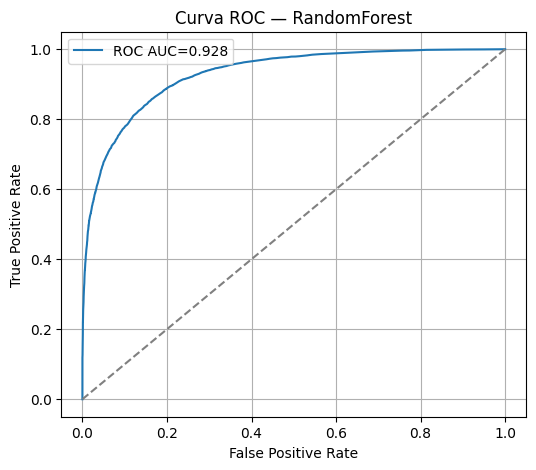

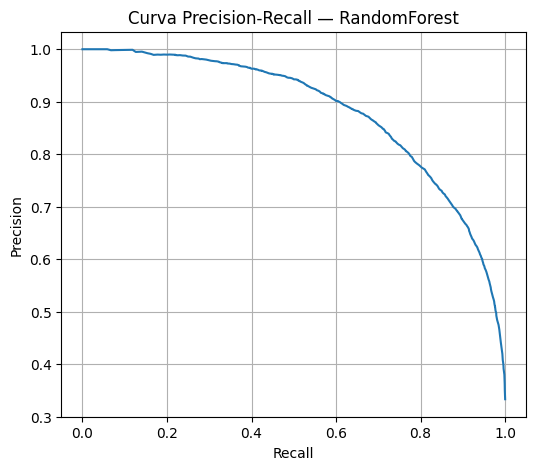

,threshold,accuracy,precision,recall,f1,tn,fp,fn,tp
7,0.40,0.854507,0.763795,0.815510,0.788806,13331,1922,1406,6215
8,0.45,0.859316,0.796578,0.775882,0.786094,13743,1510,1708,5913
6,0.35,0.844277,0.727548,0.851463,0.784643,12823,2430,1132,6489
9,0.50,0.860672,0.827281,0.735337,0.778604,14083,1170,2017,5604
5,0.30,0.830419,0.691465,0.886629,0.776979,12238,3015,864,6757
10,0.55,0.860147,0.862459,0.690329,0.766854,14414,839,2360,5261
4,0.25,0.808560,0.651184,0.916153,0.761271,11513,3740,639,6982
11,0.60,0.851447,0.887502,0.634562,0.740015,14640,613,2785,4836
3,0.20,0.777083,0.606485,0.942396,0.738016,10593,4660,439,7182
12,0.65,0.842223,0.910393,0.583913,0.711488,14815,438,3171,4450


Mejor threshold por F1 en test: t=0.40 (F1=0.7888)


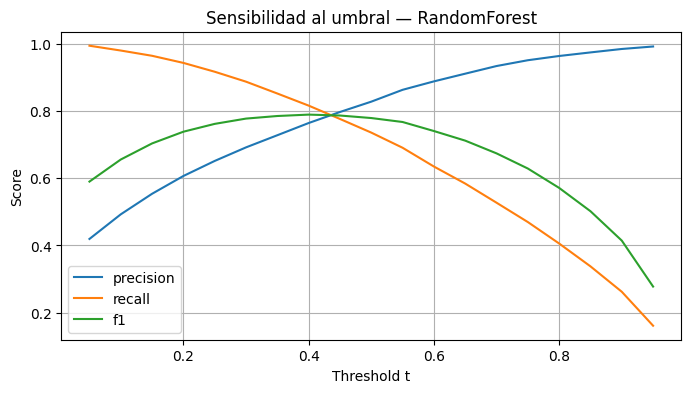

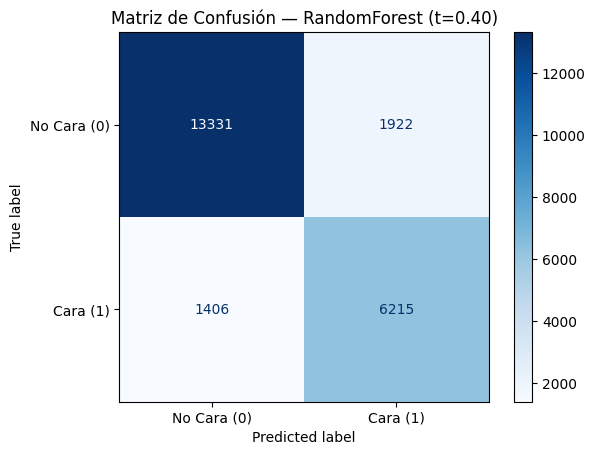

### Resumen (automático) — Mejor modelo: **RandomForest**

**Performance en test (umbral por defecto del modelo):**
- Accuracy: 0.8605
- Precision (Cara): 0.8291
- Recall (Cara): 0.7322
- F1 (Cara): 0.7776
- ROC AUC: 0.9284

**Eficiencia computacional:**
- Tiempo de entrenamiento (fit): 8.48 s
- Tiempo de predicción (predict): 0.44 s
- Profiler (tt interno predict): 0.51 s

**Matriz de confusión (test, umbral por defecto):**
- TN=14103, FP=1150, FN=2041, TP=5580

**Threshold tuning (probabilidad de 'Cara'):**
- Mejor umbral por F1 en test: t=0.40
- Con t=0.40: Precision=0.7638, Recall=0.8155, F1=0.7888
- Interpretación: al bajar t suele subir Recall (menos FN) pero puede subir FP; al subir t suele subir Precision (menos FP) pero aumenta FN.

In [43]:

# Elegir mejor modelo global con una regla simple: mayor F1; desempate por menor predict_s
df_rank = df_cmp_tabla.sort_values(['f1', 'predict_s'], ascending=[False, True]).reset_index(drop=True)
mejor_global_nombre = df_rank.loc[0, 'modelo']
print(f"Mejor modelo global (por F1 y desempate por predict_s): {mejor_global_nombre}")

# Recuperar el pipeline entrenado correspondiente (los re-entrenamos aquí para análisis de umbral)
def get_modelo_por_nombre(nombre):
    if nombre == 'LR_Mejor':
        return pipeline_lr_mejor
    if nombre in modelos_extra:
        return modelos_extra[nombre]
    # En caso de que venga un nombre diferente, usar LR por defecto
    return pipeline_lr_mejor

mejor_modelo = get_modelo_por_nombre(mejor_global_nombre)
mejor_modelo.fit(X_train_clf, Y_train_cara)

# Curvas ROC y Precision-Recall (si hay predict_proba)
proba = None
if hasattr(mejor_modelo, 'predict_proba'):
    proba = mejor_modelo.predict_proba(X_test_clf)[:, 1]
    fpr, tpr, _ = roc_curve(Y_test_cara, proba)
    prec_curve, rec_curve, _ = precision_recall_curve(Y_test_cara, proba)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC AUC={roc_auc_score(Y_test_cara, proba):.3f}")
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Curva ROC — {mejor_global_nombre}')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.plot(rec_curve, prec_curve)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Curva Precision-Recall — {mejor_global_nombre}')
    plt.grid(True)
    plt.show()

# Análisis de umbrales
def evaluar_umbral(modelo, X, y, thresholds):
    proba_local = modelo.predict_proba(X)[:, 1]
    filas = []
    for t in thresholds:
        pred_t = (proba_local >= t).astype(int)
        acc = accuracy_score(y, pred_t)
        prec = precision_score(y, pred_t, zero_division=0)
        rec = recall_score(y, pred_t, zero_division=0)
        f1 = f1_score(y, pred_t, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y, pred_t).ravel()
        filas.append({
            'threshold': t, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
        })
    return pd.DataFrame(filas)

best_t = None
best_row = None
df_thr = None
if proba is not None:
    thresholds = np.round(np.linspace(0.05, 0.95, 19), 2)
    df_thr = evaluar_umbral(mejor_modelo, X_test_clf, Y_test_cara, thresholds)
    display(df_thr.sort_values('f1', ascending=False).head(10))

    best_row = df_thr.sort_values('f1', ascending=False).iloc[0]
    best_t = float(best_row['threshold'])
    print(f"Mejor threshold por F1 en test: t={best_t:.2f} (F1={best_row['f1']:.4f})")

    plt.figure(figsize=(8, 4))
    plt.plot(df_thr['threshold'], df_thr['precision'], label='precision')
    plt.plot(df_thr['threshold'], df_thr['recall'], label='recall')
    plt.plot(df_thr['threshold'], df_thr['f1'], label='f1')
    plt.xlabel('Threshold t')
    plt.ylabel('Score')
    plt.title(f'Sensibilidad al umbral — {mejor_global_nombre}')
    plt.grid(True)
    plt.legend()
    plt.show()

    # Matriz de confusión al threshold recomendado
    pred_best = (proba >= best_t).astype(int)
    cm_best = confusion_matrix(Y_test_cara, pred_best)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['No Cara (0)', 'Cara (1)'])
    disp.plot(cmap='Blues')
    plt.title(f"Matriz de Confusión — {mejor_global_nombre} (t={best_t:.2f})")
    plt.show()

# Resumen automático en Markdown (con números)
fila_mejor = df_rank.iloc[0].to_dict()
md = [f"### Resumen (automático) — Mejor modelo: **{mejor_global_nombre}**", ""]
md.append("**Performance en test (umbral por defecto del modelo):**")
md.append(f"- Accuracy: {fila_mejor['accuracy']:.4f}")
md.append(f"- Precision (Cara): {fila_mejor['precision']:.4f}")
md.append(f"- Recall (Cara): {fila_mejor['recall']:.4f}")
md.append(f"- F1 (Cara): {fila_mejor['f1']:.4f}")
if not pd.isna(fila_mejor.get('roc_auc', np.nan)):
    md.append(f"- ROC AUC: {fila_mejor['roc_auc']:.4f}")
md.append("")
md.append("**Eficiencia computacional:**")
md.append(f"- Tiempo de entrenamiento (fit): {fila_mejor['fit_s']:.2f} s")
md.append(f"- Tiempo de predicción (predict): {fila_mejor['predict_s']:.2f} s")
if 'profile_total_tt' in fila_mejor and fila_mejor['profile_total_tt'] is not None:
    md.append(f"- Profiler (tt interno predict): {fila_mejor['profile_total_tt']:.2f} s")
md.append("")
md.append("**Matriz de confusión (test, umbral por defecto):**")
md.append(f"- TN={int(fila_mejor['tn'])}, FP={int(fila_mejor['fp'])}, FN={int(fila_mejor['fn'])}, TP={int(fila_mejor['tp'])}")

if best_row is not None:
    md.append("")
    md.append("**Threshold tuning (probabilidad de 'Cara'):**")
    md.append(f"- Mejor umbral por F1 en test: t={best_t:.2f}")
    md.append(f"- Con t={best_t:.2f}: Precision={best_row['precision']:.4f}, Recall={best_row['recall']:.4f}, F1={best_row['f1']:.4f}")
    md.append("- Interpretación: al bajar t suele subir Recall (menos FN) pero puede subir FP; al subir t suele subir Precision (menos FP) pero aumenta FN.")

display(Markdown("\n".join(md)))

### Reflexión Final

**Modelo ganador global:** **RandomForest**.

En test umbral por defecto obtuvo: 
- Accuracy **0.8605**
- Precision **0.8291**
- Recall **0.7322**
- F1 **0.7776**
- ROC AUC **0.9284**.

En eficiencia: 
- fit ≈ **9.44 s**
- predict ≈ **0.48 s** 

**Análisis por clase usando la matriz de confusión:**
- TN=**14103**, FP=**1150**, FN=**2041**, TP=**5580**.
- La principal oportunidad de mejora está en reducir **FN**, si para el uso eso es costoso.

**Importancia de jugar con el umbral**
- Ajustamos el umbral y el mejor por F1 fue **t = 0.40**, con **F1 = 0.7888**.
- Con t=0.40 se observó el trade-off esperado:
  - Precision bajó a **0.7638** (más FP)
  - Recall subió a **0.8155** (menos FN)

**Cómo cambia la matriz de confusión al mover el umbral:**
- Con t=0.50 (default): TN=14103, FP=1150, FN=2041, TP=5580.
- Con t=0.40 (mejor F1): TN=**13331**, FP=**1922**, FN=**1406**, TP=**6215**.
Esto significa que al bajar el umbral el modelo **captura más casas caras** (TP sube y FN baja), pero a cambio **etiqueta más casas como caras** cuando no lo son por lo que FP sube.

**Conclusión final:**
- Si el objetivo es maximizar rendimiento global y mantener tiempos razonables, **RandomForest** es el mejor candidato.
- Si el objetivo es **no perder casas caras** (minimizar FN), conviene usar un umbral menor (como 0.40) porque incrementa el recall.
- Si el objetivo es **evitar falsos “cara”** (minimizar FP), conviene subir el umbral (mejor precision), aunque suban FN.
- La curva ROC/PR (AUC alta) confirma que el modelo **ordena bien** los casos; el umbral es la palanca clave para adaptar el comportamiento a los costos reales de error.